In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Configure the device (GPU or CPU)
# This is vital for this assignment as CPU training is extremely slow for images
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f" Current compute device: {device}")

if device.type == 'cpu':
    print(" WARNING: You are using CPU. Image training will take a lot of time.")
else:
    print("NVIDIA GPU detected! Ready for fast training.")

# 2. Define image transformations
# Neural networks require all input images to have the exact same dimensions
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Standard size for models like VGG and AlexNet
    transforms.ToTensor(),         # Convert the image into numbers (PyTorch Tensors)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard RGB normalization
])

 Current compute device: cpu


Automatically detected classes: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
Total images loaded: 3096


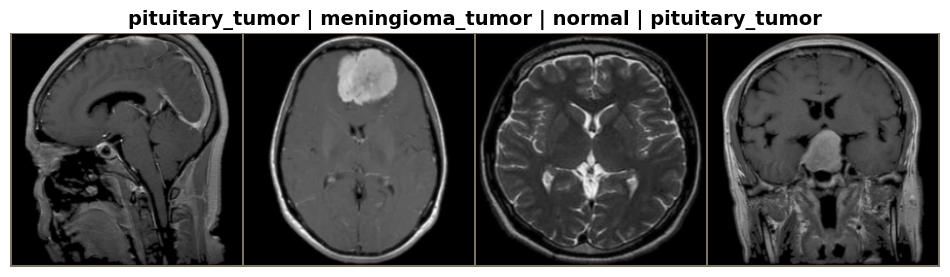

In [6]:
from torch.utils.data import DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the path to the main dataset folder
data_dir = './dataset'

# 2. ImageFolder automatically reads the folders and assigns the class labels
full_dataset = datasets.ImageFolder(root=data_dir, transform=image_transforms)

print(f"Automatically detected classes: {full_dataset.classes}")
print(f"Total images loaded: {len(full_dataset)}")

# 3. Create a DataLoader (Packages the images into batches for faster training)
# batch_size=4 means it will process 4 images at a time.
dataloader = DataLoader(full_dataset, batch_size=4, shuffle=True)

# 4. Helper function to "un-normalize" the image and display it on screen
def show_images(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0)) # Change format from PyTorch (C,H,W) to Matplotlib (H,W,C)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean # Revert the normalization so colors look natural
    inp = np.clip(inp, 0, 1)
    
    plt.figure(figsize=(12, 4))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# 5. Fetch a random batch of 4 images and display them
images, labels = next(iter(dataloader))
grid = torchvision.utils.make_grid(images)

# Get the actual string names of the classes instead of just 0, 1, 2, 3
class_names = [full_dataset.classes[label] for label in labels]
show_images(grid, title=" | ".join(class_names))